In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

<h1 style="text-align: center; color: green;">Temas selectos de Riesgo de Financiero</h1>

### Practica 6 Riesgo de común y pérdida esperada

<!-- ![image.png](attachment:image.png) -->

<div style="text-align:center">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRBzBoVxk4rqdWzm8JYC4_fxC6fa04CQWGGgQ&s" width="400">
</div>

#### Coeficiente de Gini: 

El Coeficiente de Gini se basa en la Curva de Lorenz, que es una
representación gráfica de una función de distribución acumulada. Es una medida estadística que cuantifica la desigualdad de ingresos o riqueza dentro de una población, variando de 0 (igualdad total) a 1 (desigualdad máxima). 

> cuanto más alta es la cifra, mayor es la concentración de ingresos en pocas manos.


#### Indice de Concentración de GINI.

$$ GINI = 1 - \sum_{i=1}^n (Y_i - Y_{i-1}) (X_i + X_{i-1})$$

Donde:

$X_i$: es el acumulado de empresas a partir de la más grande.

$Y_i$: es el porcentaje acumulado del monto de crédito.


- Un Gini cercano a 0 indica baja concentración. (El monto de crédito está relativamente bien distribuido entre los acreditados.
)

- Un Gini cercano a 1 indica alta concentración. (Una pequeña proporción de empresas concentra gran parte del monto de crédito.)



Valores altos del coeficiente de Gini indican que el crédito se encuentra altamente concentrado en pocos acreditados, incrementando el riesgo de concentración. Valores bajos reflejan una distribución más homogénea del portafolio y un menor riesgo común.

In [ ]:
cartera = pd.read_csv('cartera.csv')
cartera

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico
0,X22,9.316336e+06,AAA,Noreste,Agricultura,X22
1,X41,7.658337e+06,BBB,Sureste,Minería,X41
2,X92,1.644680e+06,AAA,Noreste,Agricultura,X92
3,X62,4.960432e+06,AAA,Noreste,Agricultura,X62
4,X46,7.041822e+06,BBB,Sureste,Minería,X46
...,...,...,...,...,...,...
95,X77,3.355548e+06,AAA,Noreste,Agricultura,X77
96,X58,5.279938e+06,BB,Suroeste,Manufactura,X58
97,X9,6.500000e+07,A,Centro,Hoteleria,X9
98,X32,8.323439e+06,AAA,Noreste,Agricultura,X32


In [ ]:
cartera_agrupado = cartera.sort_values('Monto de crédito', ascending=False).reset_index(drop=True)
cartera_agrupado

,Empresa,Monto de crédito
0,X1,7.500000e+07
1,X10,6.200000e+07
2,X100,1.822147e+05
3,X11,9.893193e+06
4,X12,9.797007e+06
...,...,...
95,X95,1.234157e+06
96,X96,9.865776e+05
97,X97,4.975602e+05
98,X98,3.838741e+05


In [ ]:
cartera_agrupado
cartera_agrupado

,Empresa,Monto de crédito
0,X1,7.500000e+07
12,X2,7.200000e+07
23,X3,7.100000e+07
34,X4,7.050000e+07
45,X5,7.000000e+07
...,...,...
96,X96,9.865776e+05
97,X97,4.975602e+05
98,X98,3.838741e+05
99,X99,2.676546e+05


In [ ]:
total_monto = cartera_agrupado['Monto de crédito'].sum()
total_monto

np.float64(1195844610.5686278)

In [ ]:
cartera_agrupado.index + 1

0                                                    X1
12                                                 X1X2
23                                               X1X2X3
34                                             X1X2X3X4
45                                           X1X2X3X4X5
                            ...                        
96    X1X2X3X4X5X6X7X8X9X10X11X12X13X14X15X16X17X18X...
97    X1X2X3X4X5X6X7X8X9X10X11X12X13X14X15X16X17X18X...
98    X1X2X3X4X5X6X7X8X9X10X11X12X13X14X15X16X17X18X...
99    X1X2X3X4X5X6X7X8X9X10X11X12X13X14X15X16X17X18X...
2     X1X2X3X4X5X6X7X8X9X10X11X12X13X14X15X16X17X18X...
Name: Empresa, Length: 100, dtype: object

In [ ]:
cartera_agrupado['poblacion_acum'] = range(1, len(cartera_agrupado)+1)
cartera_agrupado

,Empresa,Monto de crédito,poblacion_acum
0,X1,7.500000e+07,1
12,X2,7.200000e+07,2
23,X3,7.100000e+07,3
34,X4,7.050000e+07,4
45,X5,7.000000e+07,5
...,...,...,...
96,X96,9.865776e+05,96
97,X97,4.975602e+05,97
98,X98,3.838741e+05,98
99,X99,2.676546e+05,99


In [ ]:
proporcion_monto_acumulado = cartera_agrupado['Monto de crédito'].cumsum() / total_monto

cartera_agrupado["monto_acum"] = proporcion_monto_acumulado
cartera_agrupado

,Empresa,Monto de crédito,poblacion_acum,monto_acum
0,X1,7.500000e+07,1,0.062717
12,X2,7.200000e+07,2,0.122926
23,X3,7.100000e+07,3,0.182298
34,X4,7.050000e+07,4,0.241252
45,X5,7.000000e+07,5,0.299788
...,...,...,...,...
96,X96,9.865776e+05,96,0.998887
97,X97,4.975602e+05,97,0.999303
98,X98,3.838741e+05,98,0.999624
99,X99,2.676546e+05,99,0.999848


In [ ]:
proporcion_monto_acumulado.shift(1)

0          NaN
12    0.062717
23    0.122926
34    0.182298
45    0.241252
        ...   
96    0.998062
97    0.998887
98    0.999303
99    0.999624
2     0.999848
Name: Monto de crédito, Length: 100, dtype: float64

In [ ]:
yi_y_i_1 = proporcion_monto_acumulado - proporcion_monto_acumulado.shift(1).fillna(0)

cartera_agrupado["yi_y_i_1"] = yi_y_i_1
cartera_agrupado

,Empresa,Monto de crédito,poblacion_acum,monto_acum,yi_y_i_1
0,X1,7.500000e+07,1,0.062717,NaN
12,X2,7.200000e+07,2,0.122926,0.060208
23,X3,7.100000e+07,3,0.182298,0.059372
34,X4,7.050000e+07,4,0.241252,0.058954
45,X5,7.000000e+07,5,0.299788,0.058536
...,...,...,...,...,...
96,X96,9.865776e+05,96,0.998887,0.000825
97,X97,4.975602e+05,97,0.999303,0.000416
98,X98,3.838741e+05,98,0.999624,0.000321
99,X99,2.676546e+05,99,0.999848,0.000224


In [ ]:
Xi_X_i_1 = (cartera_agrupado['poblacion_acum'] + cartera_agrupado['poblacion_acum'].shift(1).fillna(0)) / len(cartera_agrupado)

cartera_agrupado["Xi_X_i_1"] = Xi_X_i_1
cartera_agrupado

,Empresa,Monto de crédito,poblacion_acum,monto_acum,yi_y_i_1,Xi_X_i_1
0,X1,7.500000e+07,1,0.062717,NaN,NaN
12,X2,7.200000e+07,2,0.122926,0.060208,0.03
23,X3,7.100000e+07,3,0.182298,0.059372,0.05
34,X4,7.050000e+07,4,0.241252,0.058954,0.07
45,X5,7.000000e+07,5,0.299788,0.058536,0.09
...,...,...,...,...,...,...
96,X96,9.865776e+05,96,0.998887,0.000825,1.91
97,X97,4.975602e+05,97,0.999303,0.000416,1.93
98,X98,3.838741e+05,98,0.999624,0.000321,1.95
99,X99,2.676546e+05,99,0.999848,0.000224,1.97


In [ ]:
cartera_agrupado.loc[0, "yi_y_i_1"] = proporcion_monto_acumulado.iloc[0]
cartera_agrupado.loc[0, "Xi_X_i_1"] = 1 / len(cartera_agrupado)

In [ ]:
cartera_agrupado

,Empresa,Monto de crédito,poblacion_acum,monto_acum,yi_y_i_1,Xi_X_i_1
0,X1,7.500000e+07,1,0.062717,0.062717,0.01
12,X2,7.200000e+07,2,0.122926,0.060208,0.03
23,X3,7.100000e+07,3,0.182298,0.059372,0.05
34,X4,7.050000e+07,4,0.241252,0.058954,0.07
45,X5,7.000000e+07,5,0.299788,0.058536,0.09
...,...,...,...,...,...,...
96,X96,9.865776e+05,96,0.998887,0.000825,1.91
97,X97,4.975602e+05,97,0.999303,0.000416,1.93
98,X98,3.838741e+05,98,0.999624,0.000321,1.95
99,X99,2.676546e+05,99,0.999848,0.000224,1.97


In [ ]:
gini = 1 - (cartera_agrupado['yi_y_i_1'] * cartera_agrupado['Xi_X_i_1']).sum()
print(f"Indice Gini: {gini}")

Indice Gini: 0.5906194089935973


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Por que no es ideal tener un gini cercano a 1 para nuestro caso de concentración?</li>
  </ul>
</div>

Otras aplicaciones del Gini del durante la pureza de un nodo en arbol de regresion


$$G_i = 1 - \sum_{k=1}^{n} p_i k^2$$

donde:

$G_i$ : es la pureza de Gini de un nodo.

$p_{i,k}$:es la proporción de las instancias $k$ entre las instancias en el nodo $i^{th}$.



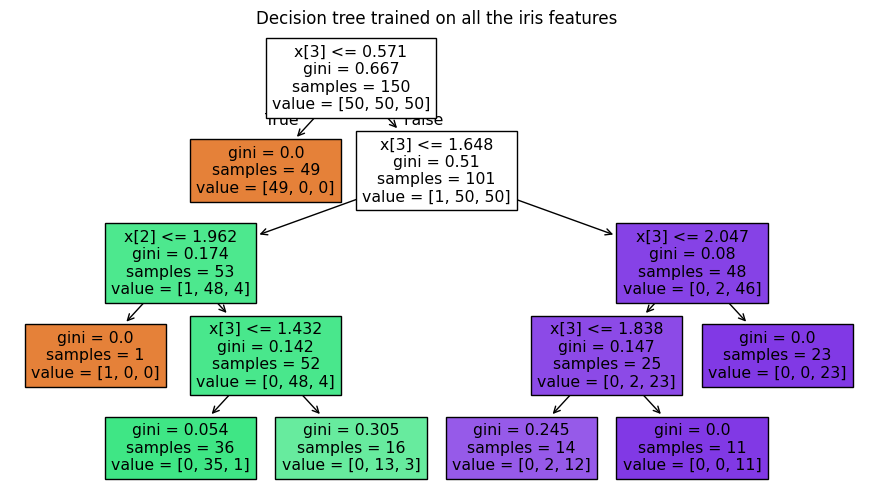

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

clf = DecisionTreeClassifier(criterion="gini", splitter="random", max_depth=4, random_state=42,min_samples_split=10).fit(X, y)

plt.figure(figsize=(11, 6))
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Realiza:
  <ul>
    <li> Calcula la impureza de Gini del último nivel del árbol (4 nodos) de manera manual usando la formula</li>    
  </ul>

Contesta 
<ul>
  <li> Que valor se recomienda tener en la pureza de Gini y por qué?.</li>
</ul>
</div>



El área bajo la curva (AUC-ROC) generada se utiliza ampliamente para medir el poder
discriminante del modelo, una área bajo la curva de 1 nos indicaría que nuestro modelo
clasifica correctamente todas las clases, mientras que un área de 0.5 nos indicaría que
nuestro modelo clasifica de manera aleatoria. 

Una forma de aproximar el AUC-ROC es utilizando el coeficiente de Gini.


$$AUCROC = \frac{1}{2}(G+1) $$

donde:

$G$: coeficiente de Gini.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> En que contexto se utiliza esta aproximación y por qué es utilizada?</li>
    <li> Escribe en que consiste la estrategia de champion–challenger. </li>
  </ul>
</div>


#### Perdida esperada

 Para fines de cálculo de las reservas para riesgos crediticios se determina multiplicando la
Probabilidad de Incumplimiento (PI) por la Severidad de la Pérdida (SP) y la Exposición al Incumplimiento (EI).

$$PE = PI \times SP \times EI$$

 
  - PI dice qué tan probable es que no pague.
  - SP dice cuánto se pierde si no paga considerando recuperaciones y garantias.
  - EI dice cuánto dinero estaba en riesgo.


| Crédito | Probabilidad de Incumplimiento (PI) | Severidad de la Pérdida (SP) | Exposición al Incumplimiento (EI) | Pérdida Esperada (PE) |
|--------|------------------------------------|-------------------------------|-----------------------------------|-----------------------|
| A      | 100%                               | 40%                           | $1,000,000                        | $400,000                |
| B      | 50%                               | 50%                           | $800,000                          | $200,000               |
| C      | 8.0%                               | 60%                           | $500,000                          | $24,000               |
| D      | 12.0%                              | 45%                           | $300,000                          | $16,200               |
| E      | 20.0%                              | 70%                           | $200,000                          | $28,000               |


In [ ]:
0.6 * 500000 * 0.08

24000.0

#### Pérdida No Esperada

La Pérdida No Esperada (PNE) o también llamada VaR de crédito se refiere a las pérdidas que se podrían
registrar en condiciones poco comunes. Una de las formas en que se puede calcular es tomando un percentil de
las pérdidas estimadas del portafolio.


In [ ]:
creditos = pd.read_csv('Cred_PE.csv')
creditos

,Credito,PI,SP,EI
0,CRED_0001,0.0999,0.3111,1464022
1,CRED_0002,0.2382,0.5251,3851250
2,CRED_0003,0.1857,0.7238,1002246
3,CRED_0004,0.1537,0.6393,69675
4,CRED_0005,0.0474,0.6839,123997
...,...,...,...,...
995,CRED_0996,0.0320,0.5942,197745
996,CRED_0997,0.2302,0.7740,3842824
997,CRED_0998,0.0428,0.2414,1780992
998,CRED_0999,0.2381,0.2342,187686


In [ ]:
creditos["PE"] = creditos["PI"] * creditos["SP"] * creditos["EI"]
creditos

,Credito,PI,SP,EI,PE
0,CRED_0001,0.0999,0.3111,1464022,45500.178696
1,CRED_0002,0.2382,0.5251,3851250,481709.805525
2,CRED_0003,0.1857,0.7238,1002246,134711.544096
3,CRED_0004,0.1537,0.6393,69675,6846.294067
4,CRED_0005,0.0474,0.6839,123997,4019.593389
...,...,...,...,...,...
995,CRED_0996,0.0320,0.5942,197745,3760.002528
996,CRED_0997,0.2302,0.7740,3842824,684694.397635
997,CRED_0998,0.0428,0.2414,1780992,18401.066865
998,CRED_0999,0.2381,0.2342,187686,10465.938172


In [ ]:
# Vector de pérdidas
losses = creditos["PE"]

# Expected Loss (media) y un umbral para Capital (percentil alto)
EL = losses.mean()
q = 0.995                      # puedes usar 0.995 o 0.999 según tu caso
VaR = np.percentile(losses, q*100)  # percentil q de la distribución
UL = VaR - EL                 # Unexpected Loss como exceso sobre EL

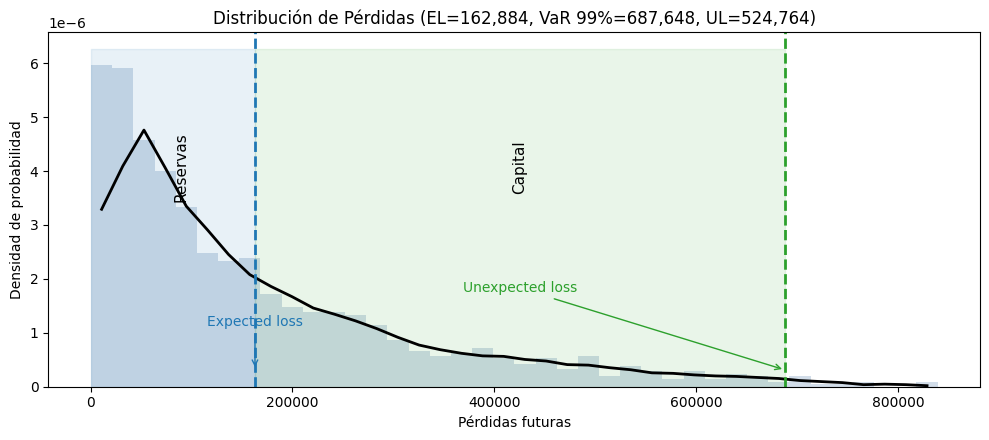

In [ ]:
# Histograma + densidad (KDE aproximada con hist)
fig, ax = plt.subplots(figsize=(10, 4.5))

# Histograma en densidad
n, bins, patches = ax.hist(losses, bins=40, density=True, alpha=0.25, color="#4C78A8", edgecolor="none")

# Línea suave aproximada (usando el centro de bins y un suavizado simple)
centers = 0.5*(bins[1:] + bins[:-1])

# Suavizado (moving average) para simular curva tipo densidad
window = 5
kernel = np.ones(window)/window
smooth = np.convolve(n, kernel, mode="same")
ax.plot(centers, smooth, color="black", linewidth=2)

# Líneas verticales (EL y VaR)
ax.axvline(EL, color="#1F77B4", linestyle="--", linewidth=2)
ax.axvline(VaR, color="#2CA02C", linestyle="--", linewidth=2)

# 5) Sombreado: Reservas (0 a EL) y Capital (EL a VaR)
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], 0, EL, color="#1F77B4", alpha=0.10)
ax.fill_betweenx([0, ymax], EL, VaR, color="#2CA02C", alpha=0.10)

# 6) Etiquetas como la imagen
ax.set_ylabel("Densidad de probabilidad")
ax.set_xlabel("Pérdidas futuras")
ax.text(EL*0.55, ymax*0.65, "Reservas", rotation=90, va="center", ha="center", fontsize=11)
ax.text((EL+VaR)/2, ymax*0.65, "Capital", rotation=90, va="center", ha="center", fontsize=11)

# Anotaciones
ax.annotate("Expected loss",
            xy=(EL, ymax*0.05), xytext=(EL, ymax*0.18),
            arrowprops=dict(arrowstyle="->", color="#1F77B4"),
            ha="center", color="#1F77B4")

ax.annotate("Unexpected loss",
            xy=(VaR, ymax*0.05), xytext=((EL+VaR)/2, ymax*0.28),
            arrowprops=dict(arrowstyle="->", color="#2CA02C"),
            ha="center", color="#2CA02C")

ax.set_title(f"Distribución de Pérdidas (EL={EL:,.0f}, VaR {int(q*100)}%={VaR:,.0f}, UL={UL:,.0f})")
plt.tight_layout()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Por qué no basta con conocer solo la PI para medir el riesgo?</li>
    <li> ¿Qué representa cada punto de la distribución?</li>
    <li> ¿Por qué la distribución es asimétrica y con cola derecha? </li>
    <li> ¿Qué representa el área a la derecha del VaR? </li>
  </ul>
</div>


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Realiza nuevamente el ejercicio haciendo la simulación de 1000 créditos.
  <ul>
    <li> Simula la probabilidad incumplimiento (PI) usando variables Bernoulli. </li>
    <li> Simula la exposición al incumplimiento (EI) usando variables lognormal. </li>
    <li> Simula la severidad de la perdida (SP) usando variables betas (distribución beta). </li>
    <li> Obtén pérdida esperada y perdida no esperada (VaR 95% confianza) </li>
    <li> Grafica el histograma de pérdidas. </li>
    <li> Marca la perdida esperada y no esperada. </li>
    <li> Sombrea la Reserva y Capital </li>
  </ul>
</div>
